#**Trabalho Análise Exploratória de Dados - Inteligência Artificial - UFF**
O trabalho foi feito a partir de uma base de dados dos anos de 2018-2024 da Formula 1.
###Autor: Samuel Detone Dutra

Dados utilizados foram obtidos do Kaggle.
Link: https://www.kaggle.com/datasets/akashrane2609/f1-stint-data-with-aggression-scores

In [1]:
# Bibliotecas que serão utilizadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Leitura do DataSet que será utilizado.

In [2]:

# ID Extraído do link
#file_id = '10kB72MiIN4UOuI6NehgP2tKMazi0O6nL'

# URL de Download Direto
#url_direta = f'https://drive.google.com/uc?export=download&id={file_id}'

# Leitura
df = pd.read_csv("f1_pitstops_2018_2024.csv")

# Visualização da Estrutura

In [3]:
df.head()

,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
0,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,1.0,ULTRASOFT,25.0,26.0,21.787
1,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,2.0,SOFT,32.0,NaN,Final Stint
2,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,1.0,ULTRASOFT,17.0,19.0,21.821
3,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,2.0,SOFT,39.0,NaN,Final Stint
4,2018,1,Albert Park Grand Prix Circuit,Kimi RÃƒÂ¤ikkÃƒÂ¶nen,Ferrari,58,3,1,21.421,Australian Grand Prix,...,0.017241,45.13482,0.086957,6.818562,RAI,1.0,ULTRASOFT,17.0,18.0,21.421


In [4]:
df.tail()

,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
7369,2024,24,Yas Marina Circuit,Valtteri Bottas,Sauber,30,18,1,41.144,Abu Dhabi Grand Prix,...,0.033333,25.41182,0.739130,3.930495,BOT,1.0,MEDIUM,6.0,6.0,41.144
7370,2024,24,Yas Marina Circuit,Valtteri Bottas,Sauber,30,18,1,41.144,Abu Dhabi Grand Prix,...,0.033333,25.41182,0.739130,3.930495,BOT,2.0,HARD,24.0,NaN,Final Stint
7371,2024,24,Yas Marina Circuit,Franco Colapinto,Williams,26,19,1,24.941,Abu Dhabi Grand Prix,...,0.038462,41.61482,0.782609,6.364719,COL,1.0,MEDIUM,3.0,3.0,24.941
7372,2024,24,Yas Marina Circuit,Franco Colapinto,Williams,26,19,1,24.941,Abu Dhabi Grand Prix,...,0.038462,41.61482,0.782609,6.364719,COL,2.0,HARD,23.0,NaN,Final Stint
7373,2024,24,Yas Marina Circuit,Sergio PÃƒÂ©rez,Red Bull,0,20,0,NaN,Abu Dhabi Grand Prix,...,NaN,NaN,0.826087,NaN,PER,1.0,MEDIUM,1.0,NaN,NaN


In [5]:
df.shape

(7374, 30)

# Correção do nome dos pilotos que se encontravam errados no dataset.

In [6]:
df['Driver'] = df['Driver'].replace('.*Kimi R.*', 'Kimi Räikkönen', regex=True)
df['Driver'] = df['Driver'].replace('.*Sergio P.*', 'Sergio Pérez', regex=True)
df['Driver'] = df['Driver'].replace('.*lkenberg.*', 'Nico Hülkenberg', regex=True)

#Visualização da estrutura com a correção do nomes errados.

In [7]:
df.head()

,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
0,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,1.0,ULTRASOFT,25.0,26.0,21.787
1,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,2.0,SOFT,32.0,NaN,Final Stint
2,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,1.0,ULTRASOFT,17.0,19.0,21.821
3,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,2.0,SOFT,39.0,NaN,Final Stint
4,2018,1,Albert Park Grand Prix Circuit,Kimi Räikkönen,Ferrari,58,3,1,21.421,Australian Grand Prix,...,0.017241,45.13482,0.086957,6.818562,RAI,1.0,ULTRASOFT,17.0,18.0,21.421


In [8]:
df.tail()

,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
7369,2024,24,Yas Marina Circuit,Valtteri Bottas,Sauber,30,18,1,41.144,Abu Dhabi Grand Prix,...,0.033333,25.41182,0.739130,3.930495,BOT,1.0,MEDIUM,6.0,6.0,41.144
7370,2024,24,Yas Marina Circuit,Valtteri Bottas,Sauber,30,18,1,41.144,Abu Dhabi Grand Prix,...,0.033333,25.41182,0.739130,3.930495,BOT,2.0,HARD,24.0,NaN,Final Stint
7371,2024,24,Yas Marina Circuit,Franco Colapinto,Williams,26,19,1,24.941,Abu Dhabi Grand Prix,...,0.038462,41.61482,0.782609,6.364719,COL,1.0,MEDIUM,3.0,3.0,24.941
7372,2024,24,Yas Marina Circuit,Franco Colapinto,Williams,26,19,1,24.941,Abu Dhabi Grand Prix,...,0.038462,41.61482,0.782609,6.364719,COL,2.0,HARD,23.0,NaN,Final Stint
7373,2024,24,Yas Marina Circuit,Sergio Pérez,Red Bull,0,20,0,NaN,Abu Dhabi Grand Prix,...,NaN,NaN,0.826087,NaN,PER,1.0,MEDIUM,1.0,NaN,NaN


# Tipos de váriaveis utilizadas no Data Frame

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7374 entries, 0 to 7373
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Season                   7374 non-null   int64  
 1   Round                    7374 non-null   int64  
 2   Circuit                  7374 non-null   object 
 3   Driver                   7374 non-null   object 
 4   Constructor              7374 non-null   object 
 5   Laps                     7374 non-null   int64  
 6   Position                 7374 non-null   int64  
 7   TotalPitStops            7374 non-null   int64  
 8   AvgPitStopTime           7189 non-null   float64
 9   Race Name                7001 non-null   object 
 10  Date                     7001 non-null   object 
 11  Time_of_race             7001 non-null   object 
 12  Location                 7001 non-null   object 
 13  Country                  7001 non-null   object 
 14  Air_Temp_C              

# Estatísticas Descritivas

In [10]:
df.describe()

,Season,Round,Laps,Position,TotalPitStops,AvgPitStopTime,Air_Temp_C,Track_Temp_C,Humidity_%,Wind_Speed_KMH,Lap Time Variation,Total Pit Stops,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Stint,Stint Length,Pit_Lap
count,7374.000000,7374.000000,7374.000000,7374.000000,7374.000000,7189.000000,7001.000000,7001.000000,7001.000000,7001.000000,7189.000000,7374.000000,7308.000000,7189.000000,7374.000000,7189.000000,7265.000000,7265.000000,4564.000000
mean,2021.308245,10.673312,56.643748,10.156089,2.068348,120.109095,19.520345,25.207104,67.576191,11.434032,0.034075,0.295478,0.038443,124.167364,0.398091,18.757830,2.048727,20.222987,26.127082
std,1.969604,6.135126,13.922667,5.590062,1.135088,268.723688,5.092982,5.195562,14.157319,6.073363,0.088420,0.162155,0.031907,244.256205,0.243046,36.674194,1.068210,12.612483,15.351605
min,2018.000000,1.000000,0.000000,1.000000,0.000000,17.358500,0.387500,5.887500,18.375000,3.362500,0.000266,0.000000,0.000000,3.191820,0.000000,0.588407,1.000000,1.000000,1.000000
25%,2020.000000,5.000000,52.000000,5.000000,1.000000,22.388000,15.958333,21.587500,60.500000,6.804167,0.001921,0.142857,0.019608,40.916320,0.173913,6.257962,1.000000,11.000000,14.000000
50%,2021.000000,11.000000,57.000000,10.000000,2.000000,24.414000,19.633333,25.175000,70.500000,9.408333,0.002588,0.285714,0.035088,43.384153,0.391304,6.623602,2.000000,19.000000,26.000000
75%,2023.000000,15.000000,66.000000,15.000000,3.000000,30.068000,23.750000,29.504167,77.291667,15.550000,0.004448,0.428571,0.045455,45.331820,0.608696,6.908705,3.000000,28.000000,37.000000
max,2024.000000,24.000000,87.000000,20.000000,7.000000,3055.732000,33.295833,39.795833,94.333333,35.908333,1.000000,1.000000,1.000000,2989.176180,0.826087,448.791707,8.000000,77.000000,78.000000


In [11]:
df.median(numeric_only=True)

Season                     2021.000000
Round                        11.000000
Laps                         57.000000
Position                     10.000000
TotalPitStops                 2.000000
AvgPitStopTime               24.414000
Air_Temp_C                   19.633333
Track_Temp_C                 25.175000
Humidity_%                   70.500000
Wind_Speed_KMH                9.408333
Lap Time Variation            0.002588
Total Pit Stops               0.285714
Tire Usage Aggression         0.035088
Fast Lap Attempts            43.384153
Position Changes              0.391304
Driver Aggression Score       6.623602
Stint                         2.000000
Stint Length                 19.000000
Pit_Lap                      26.000000
dtype: float64

In [12]:
# Moda das Colunas Númericas.

colunas_numericas = df.select_dtypes(include='number')

# Loop que passa de coluna a coluna, uma por uma.
for coluna in colunas_numericas.columns:

    # Calcula a moda, remove os valores nulos da conta e transforma numa lista limpa (para Null não ser Moda)
    modas = df[coluna].mode().dropna().tolist()

    # Imprime o resultado
    print(f"{coluna}: {modas}")

Season: [2023]
Round: [11]
Laps: [57]
Position: [13]
TotalPitStops: [2]
AvgPitStopTime: [20.935, 21.942, 23.34633333, 25.439, 363.6627143, 365.6031429, 428.5118333]
Air_Temp_C: [12.816666666666665]
Track_Temp_C: [18.316666666666663]
Humidity_%: [77.95833333333333]
Wind_Speed_KMH: [24.091666666666665]
Lap Time Variation: [0.001443151, 0.00177449, 0.002236566, 0.002925128, 0.1142128375619368, 0.1148513080324547, 0.1355505191033248]
Total Pit Stops: [0.2857142857142857]
Tire Usage Aggression: [0.035714286]
Fast Lap Attempts: [41.11681994581159, 43.20948661581159, 44.61381994581159, 45.62081994581159, 297.1068943541884, 299.0473229541884, 361.9560133541884]
Position Changes: [0.5217391304347826]
Driver Aggression Score: [6.659337153759244, 44.91322070971084, 45.21317219302591, 54.634584757202944]
Stint: [1.0]
Stint Length: [1.0]
Pit_Lap: [1.0]


# Identificação de Outliers e Inconsistências nos Dados

In [13]:
# Inconsistências (Erros nos Dados)

# Procura linha duplicadas
duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicadas}")

# Procura valores nulos (Faltantes)
print("\nValores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Procura erros de lógica (Como por exemplo, PitStop negativo.)
df['Pit_Time'] = pd.to_numeric(df['Pit_Time'], errors='coerce')
erros_tempo = df[df['Pit_Time'] <= 0]
print(f"\nPit stops com tempo inválido (<= 0): {len(erros_tempo)}")

# Erros de lógica cruzada (Como por exemplo, PitStop ocorrendo em uma volta maior que o total de voltas da corrida)
df_valido = df.dropna(subset=['Pit_Lap', 'Laps'])
erros_voltas = df_valido[df_valido['Pit_Lap'] > df_valido['Laps']]
print(f"Pit stops em voltas impossíveis: {len(erros_voltas)}")

Linhas duplicadas: 0

Valores nulos por coluna:
AvgPitStopTime              185
Race Name                   373
Date                        373
Time_of_race                373
Location                    373
Country                     373
Air_Temp_C                  373
Track_Temp_C                373
Humidity_%                  373
Wind_Speed_KMH              373
Lap Time Variation          185
Tire Usage Aggression        66
Fast Lap Attempts           185
Driver Aggression Score     185
Stint                       109
Tire Compound               109
Stint Length                109
Pit_Lap                    2810
Pit_Time                    281
dtype: int64

Pit stops com tempo inválido (<= 0): 0
Pit stops em voltas impossíveis: 0


In [14]:
# Limpeza dessas Inconsistências.

# Copiar o df original para um novo, por segurança.
df_limpo = df.copy()

# Deletando todas as linhas onde não houve pit stop real
# (ou seja, onde Pit_Time ou Pit_Lap ficaram vazios após nossa conversão)
df_limpo = df_limpo.dropna(subset=['Pit_Time', 'Pit_Lap'])
print(f"Linhas após remover os 'Final Stints': {len(df_limpo)}")

# Para o clima, preenchemos os valores vazios com a MEDIANA DA PRÓPRIA CORRIDA
colunas_clima = ['Air_Temp_C', 'Track_Temp_C', 'Humidity_%', 'Wind_Speed_KMH']

for col in colunas_clima:
    # Agrupa por Temporada e Nome da Corrida para preencher com a mediana local
    df_limpo[col] = df_limpo.groupby(['Season', 'Race Name'])[col].transform(lambda x: x.fillna(x.median()))

    # Se uma corrida inteira estiver sem sensor, preenche o que sobrou com a mediana geral
    df_limpo[col] = df_limpo[col].fillna(df_limpo[col].median())

print("\nValores nulos agora nas colunas de clima (após ajuste por corrida):")
print(df_limpo[colunas_clima].isnull().sum())

Linhas após remover os 'Final Stints': 4564

Valores nulos agora nas colunas de clima (após ajuste por corrida):
Air_Temp_C        0
Track_Temp_C      0
Humidity_%        0
Wind_Speed_KMH    0
dtype: int64


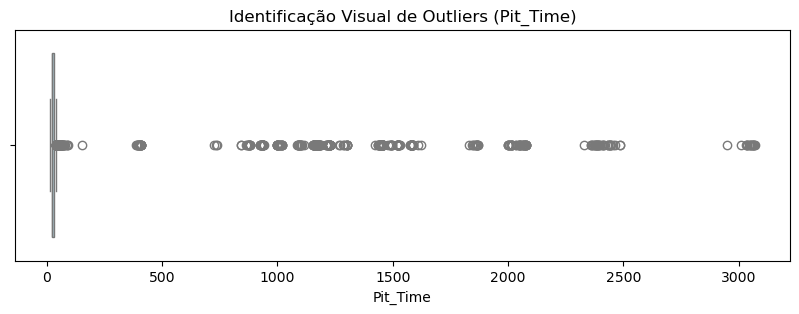

In [15]:
# Outliers (Valores Atípicos)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
# Criando um boxplot horizontal do tempo de pit stop
sns.boxplot(x=df['Pit_Time'], color='lightblue')
plt.title('Identificação Visual de Outliers (Pit_Time)')
plt.show()

In [16]:
# Identificando e separando Outliers do Código.


# Será utilizado o Método Estatístico: Intervalo Interquartil


# Definir os quartis para a coluna Pit_Time
Q1 = df['Pit_Time'].quantile(0.25)
Q3 = df['Pit_Time'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites aceitáveis
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Qualquer pit stop abaixo de {limite_inferior:.2f}s ou acima de {limite_superior:.2f}s é outlier.")

# Filtrar a tabela para ver quem são esses outliers
outliers = df[(df['Pit_Time'] < limite_inferior) | (df['Pit_Time'] > limite_superior)]
print(f"\nTotal de Outliers encontrados: {len(outliers)}")

# Mostrando os 5 PitStops mais longos
print("\nTop 5 Pit Stops mais longos (Outliers):")
print(outliers[['Season', 'Driver', 'Constructor', 'Race Name', 'Pit_Time']].sort_values(by='Pit_Time', ascending=False).head())

Qualquer pit stop abaixo de 11.83s ou acima de 39.24s é outlier.

Total de Outliers encontrados: 427

Top 5 Pit Stops mais longos (Outliers):
      Season            Driver   Constructor           Race Name  Pit_Time
4223    2022      Lance Stroll  Aston Martin  British Grand Prix  3069.017
4216    2022  Sebastian Vettel  Aston Martin  British Grand Prix  3067.301
4212    2022   Mick Schumacher  Haas F1 Team  British Grand Prix  3065.174
4220    2022   Kevin Magnussen  Haas F1 Team  British Grand Prix  3063.613
4231    2022  Daniel Ricciardo       McLaren  British Grand Prix  3063.314


Um padrão que pode ser observado foi no British Grand Prix de 2022 os 5 maiores PitStops ocorreram, essa corrida ficou marcada pelo acidente grave na largada do incidente com o piloto Chinês Zhou Guanyu, além da corrida ser interrompida com bandeira vermelha, fazendo com que essas maiores contagens fossem em bandeira vermelha por isso tão altas.

# Análise de correlação entre variáveis

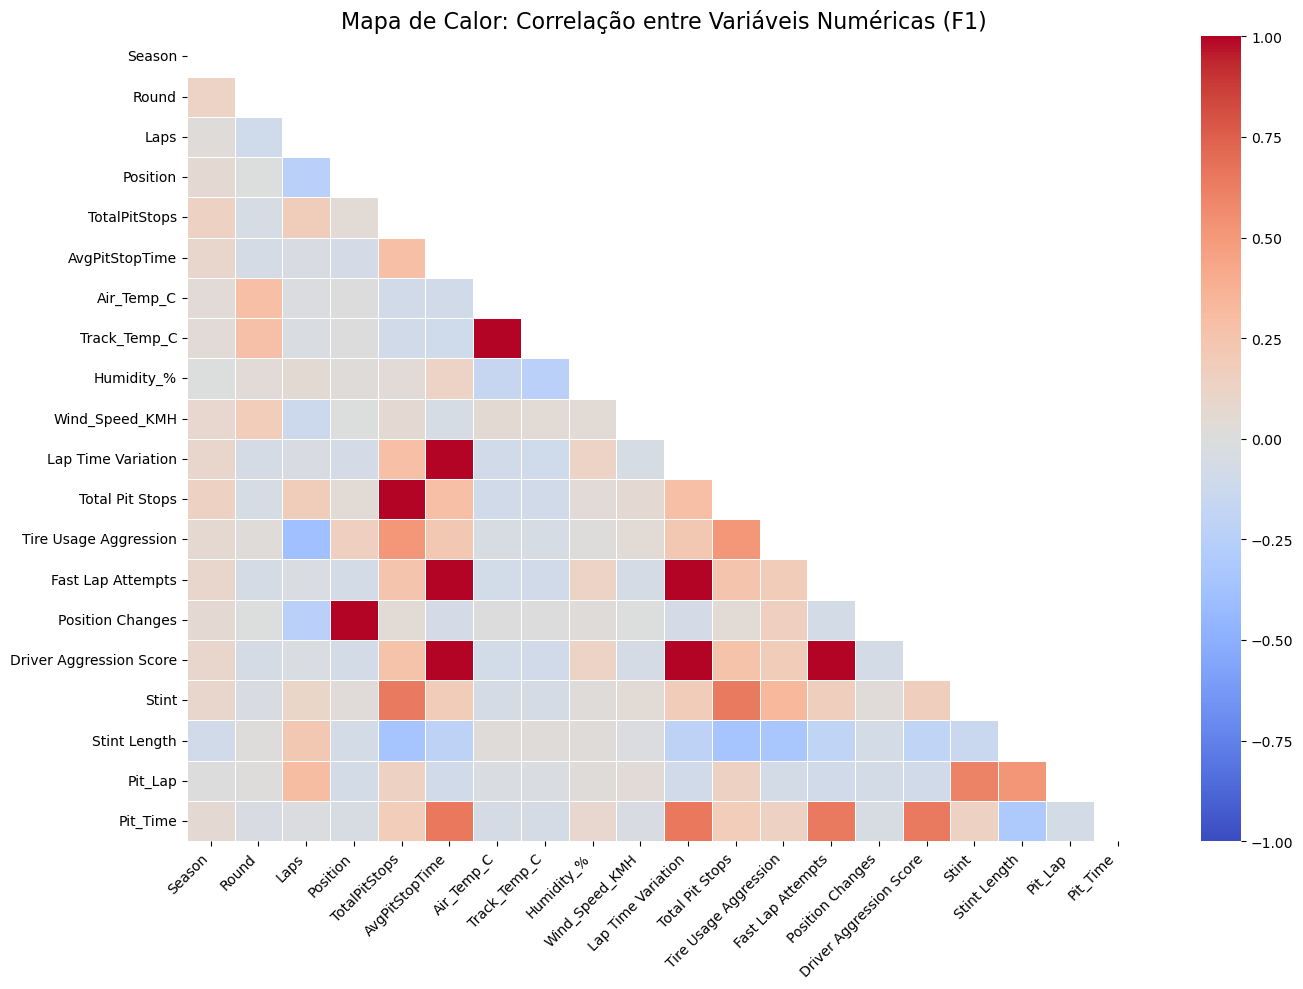


Top variáveis que mais se correlacionam com o Tempo do Pit Stop:
AvgPitStopTime             0.650571
Lap Time Variation         0.650571
Driver Aggression Score    0.648233
Fast Lap Attempts          0.648203
Stint Length               0.310999
Name: Pit_Time, dtype: float64


In [17]:


# Selecionamos apenas as colunas que têm números (correlação não funciona com texto)
df_numerico = df_limpo.select_dtypes(include=['float64', 'int64'])

# Calculamos a matriz de correlação (vai de -1 a 1)
matriz_corr = df_numerico.corr()

# Desenhar o gráfico
plt.figure(figsize=(14, 10))

# Criar uma "máscara" para cortar a metade superior do gráfico (pois ela é repetida)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Gerar o Mapa de Calor
sns.heatmap(matriz_corr,
            mask=mascara,
            cmap='coolwarm',  # Cores: azul (negativo), branco (zero), vermelho (positivo)
            annot=False,
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas (F1)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Maiores correlações com o Tempo de Pit Stop (Target)
print("\nTop variáveis que mais se correlacionam com o Tempo do Pit Stop:")
# Ordenamos do maior para o menor impacto (seja positivo ou negativo)
corr_pit = matriz_corr['Pit_Time'].drop('Pit_Time').abs().sort_values(ascending=False)
print(corr_pit.head(5))

# Visualizações gráficas

Média de Voltas na Pista por Composto de Pneu
  Tire Compound  Stint Length
0     SUPERSOFT     23.655556
1     ULTRASOFT     22.257426
2          HARD     21.846596
3        MEDIUM     17.497091
4          SOFT     15.486028
5     HYPERSOFT     14.883721
6  INTERMEDIATE     14.223242
7           WET      5.850746


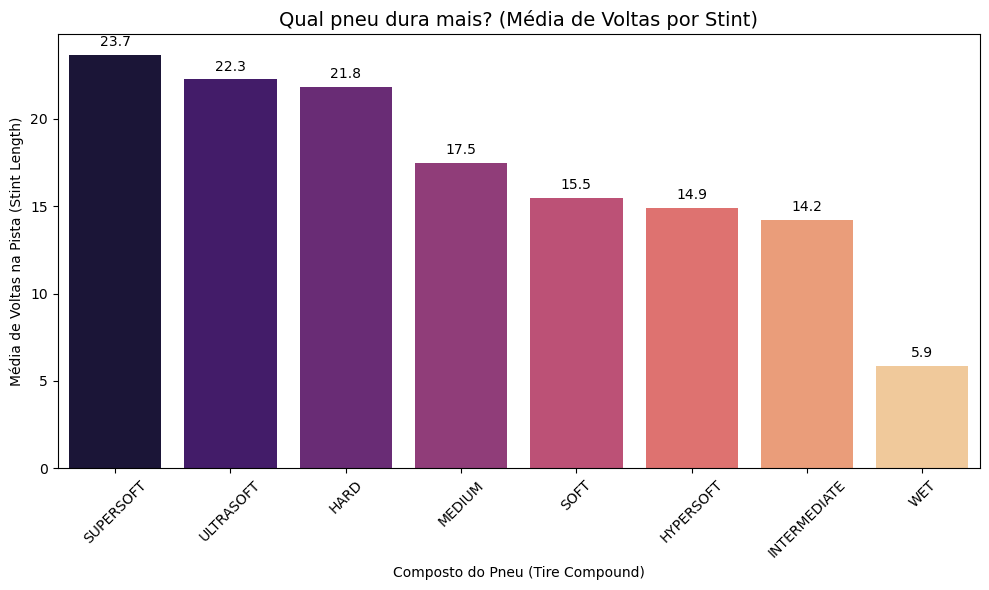

In [18]:
# Gráfico de Barra


print("Média de Voltas na Pista por Composto de Pneu")

# Agrupar por pneu e calcular a média do comprimento do Stint
stint_por_pneu = df_limpo.groupby('Tire Compound')['Stint Length'].mean().sort_values(ascending=False).reset_index()

# Mostrar a tabela em texto
print(stint_por_pneu)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))

sns.barplot(data=stint_por_pneu, x='Tire Compound', y='Stint Length', hue='Tire Compound', palette='magma', legend=False)

plt.title('Qual pneu dura mais? (Média de Voltas por Stint)', fontsize=14)
plt.xlabel('Composto do Pneu (Tire Compound)')
plt.ylabel('Média de Voltas na Pista (Stint Length)')
plt.xticks(rotation=45) # Nome dos pneus inclinados para não baterem uns nos outros

# Números em cima de cada barra
for index, row in stint_por_pneu.iterrows():
    plt.text(index, row['Stint Length'] + 0.5, round(row['Stint Length'], 1), color='black', ha="center")

plt.tight_layout()
plt.show()

Os compostos como ULTRASOFT e SUPERSOFT apresentaram médias de stint relativamente altas, próximas ou superiores às observadas para o HARD em alguns períodos.

Gerando gráfico: Pódios por Equipe e Piloto...


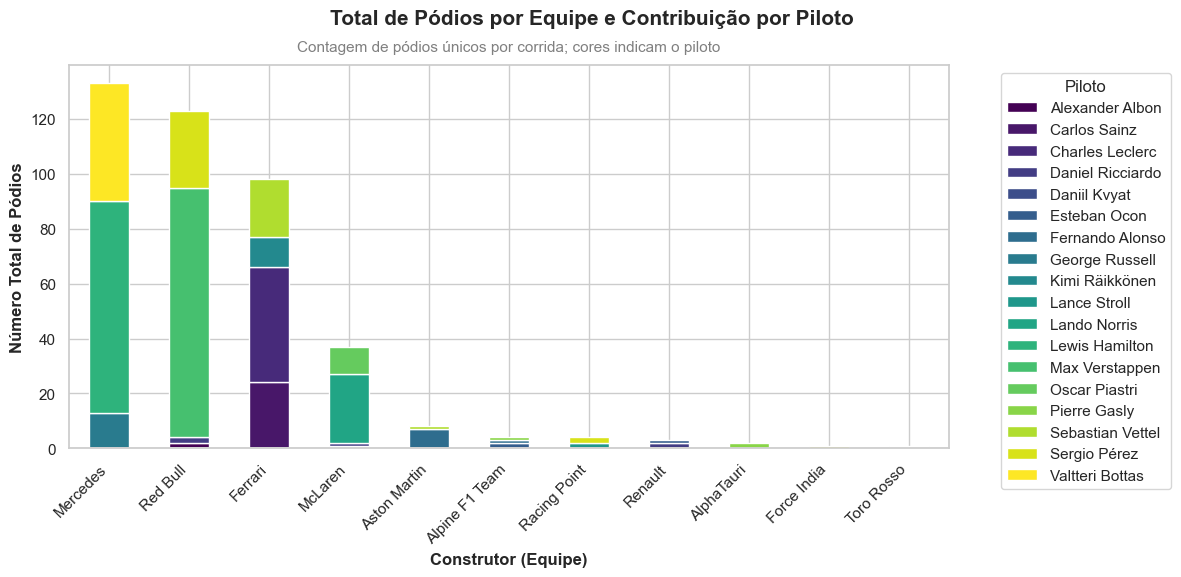

In [19]:
# Gráfico de Barra

print("Gerando gráfico: Pódios por Equipe e Piloto...")

# Filtrar apenas resultados de pódio e remover repetições
# Como o dataset está em nível de stint, um piloto pode aparecer várias vezes
# na mesma corrida. Aqui vai ser contado apenas um pódio por piloto/corrida.
df_podios_unicos = (
    df_limpo[df_limpo['Position'] <= 3]
    .drop_duplicates(subset=['Season', 'Round', 'Driver', 'Position'])
)

# Agrupar por Construtor e Piloto e contar pódios únicos
tabela_podios = (
    df_podios_unicos
    .groupby(['Constructor', 'Driver'])
    .size()
    .unstack(fill_value=0)
)

# Ordenar as equipes que têm mais pódios
tabela_podios['Total'] = tabela_podios.sum(axis=1)
tabela_podios = tabela_podios.sort_values('Total', ascending=False)
tabela_podios = tabela_podios.drop(columns='Total')

sns.set_theme(style="whitegrid")

ax = tabela_podios.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    cmap='viridis',
    edgecolor='white',
    linewidth=1
)

plt.suptitle(
    "Total de Pódios por Equipe e Contribuição por Piloto",
    fontsize=15,
    fontweight='bold',
    y=0.96
)

plt.title(
    "Contagem de pódios únicos por corrida; cores indicam o piloto",
    fontsize=11,
    color='gray',
    pad=10
)

plt.xlabel("Construtor (Equipe)", fontweight='bold')
plt.ylabel("Número Total de Pódios", fontweight='bold')

plt.xticks(rotation=45, ha='right')

plt.legend(
    title="Piloto",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

É possível notar que as equipes que mais brigaram por título no período dos dados (2018 - 2024) são as equipes com mais pódios, com destaque para Max Verstappen e Lewis Hamilton que figuraram batalhas por vitórias históricas.

Gerando gráfico: Efeito da Temperatura (Eixos Centralizados estilo R)...


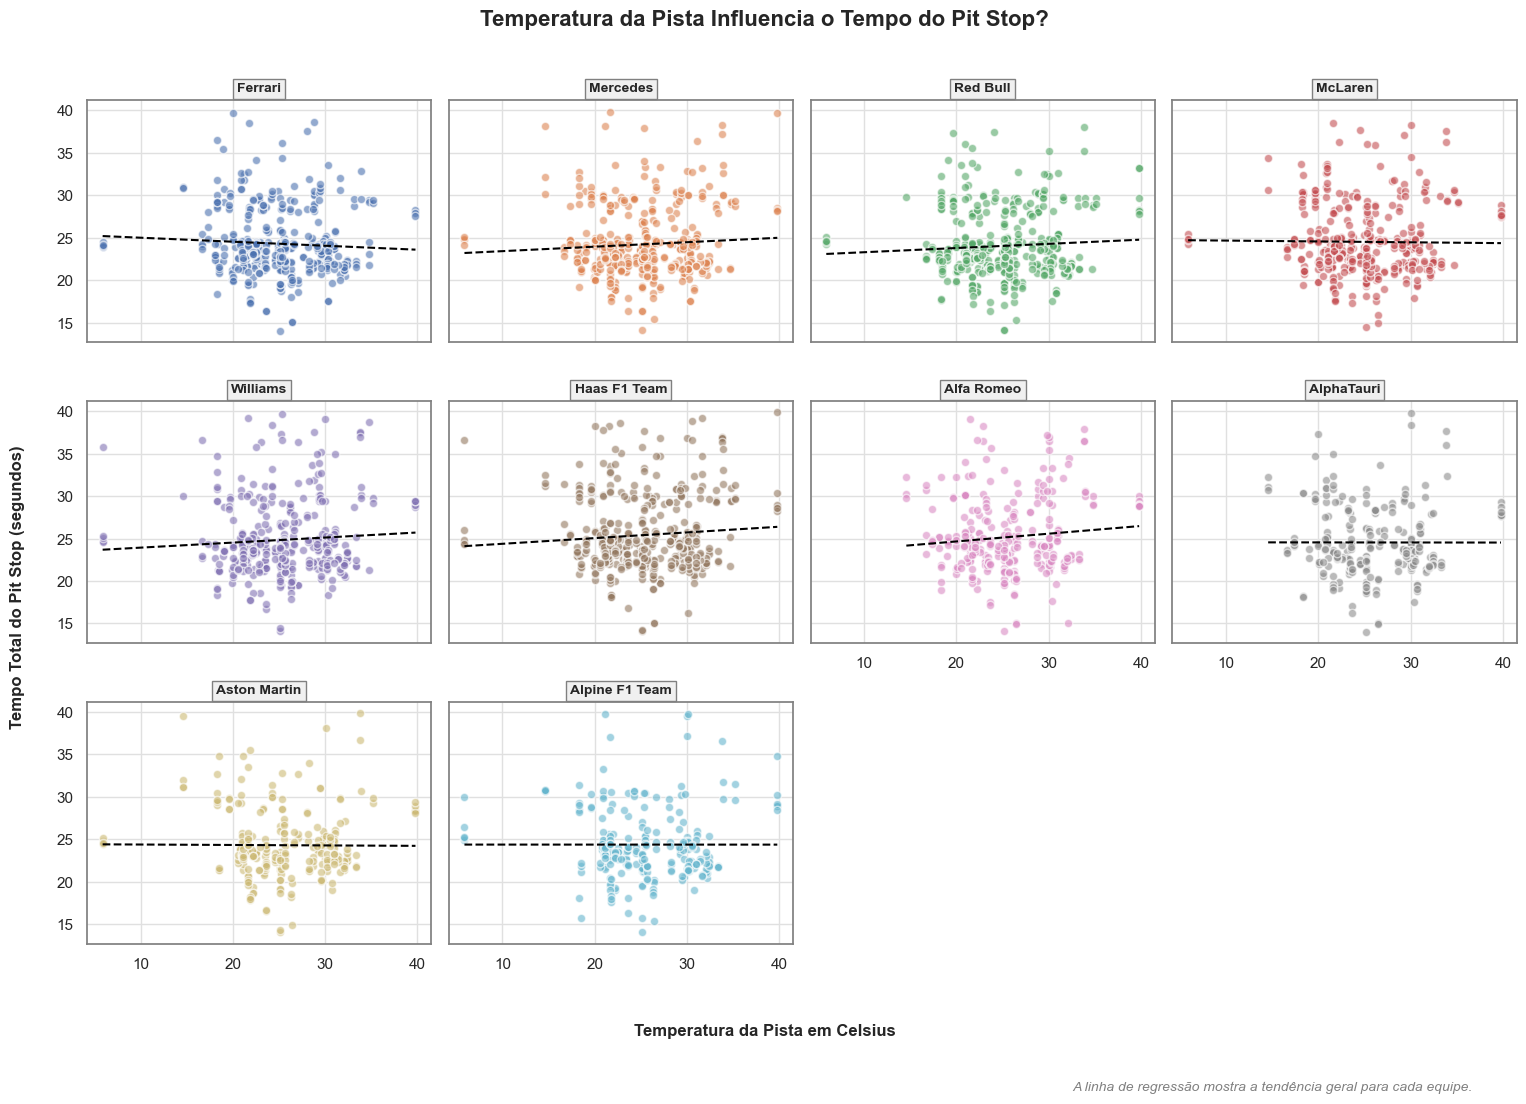

In [20]:
# Gráfico de Dispersão

print("Gerando gráfico: Efeito da Temperatura")

# Filtro de segurança
df_pitstops_clean = df_limpo.dropna(subset=['Track_Temp_C', 'Pit_Time', 'Constructor'])
df_pitstops_clean = df_pitstops_clean[df_pitstops_clean['Pit_Time'] <= 40]

# Filtrar as Top 10 equipes
top_10_equipes = df_pitstops_clean['Constructor'].value_counts().nlargest(10).index
df_pitstops_clean = df_pitstops_clean[df_pitstops_clean['Constructor'].isin(top_10_equipes)]

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "gray", "grid.color": "#e0e0e0"})

# Criar o painel de gráficos (facetas)
g = sns.lmplot(
    data=df_pitstops_clean,
    x='Track_Temp_C',
    y='Pit_Time',
    col='Constructor',
    hue='Constructor',
    col_wrap=4,
    ci=None,
    height=3.5,
    aspect=1.1,
    legend=False,
    scatter_kws={'alpha': 0.6, 'edgecolor': 'w'},
    line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 1.5}
)

g.despine(top=False, right=False)

for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(
        title,
        fontsize=10,
        fontweight='bold',
        bbox=dict(facecolor='#f0f0f0', edgecolor='gray', boxstyle='square,pad=0.3')
    )


# Apagando os nomes dos eixos individuais que o Seaborn coloca debaixo de cada coluna
g.set_axis_labels("", "")

# Título único centralizado debaixo de toda a figura para o eixo X
g.fig.supxlabel("Temperatura da Pista em Celsius", fontweight='bold', fontsize=12, y=0.07)

# Título único centralizado à esquerda da figura para o eixo Y
g.fig.supylabel("Tempo Total do Pit Stop (segundos)", fontweight='bold', fontsize=12, x=0.01)
g.fig.suptitle("Temperatura da Pista Influencia o Tempo do Pit Stop?", fontsize=16, fontweight='bold', y=1.05)
g.fig.subplots_adjust(bottom=0.16, left=0.06)
g.fig.text(0.96, 0.02, "A linha de regressão mostra a tendência geral para cada equipe.",
           ha='right', fontsize=10, color='gray', style='italic')

plt.show()

A temperatura da pista influencia o tempo de pit stop, mas a magnitude desse impacto varia entre os construtores. Algumas equipes podem ser mais eficientes em se adaptar a condições de calor, enquanto outras enfrentam maiores dificuldades. Esse fenômeno pode ser importante para otimizar estratégias de pit stop em diferentes condições climáticas durante as corridas.

Gráfico: Agressividade vs Desgaste com Cores...


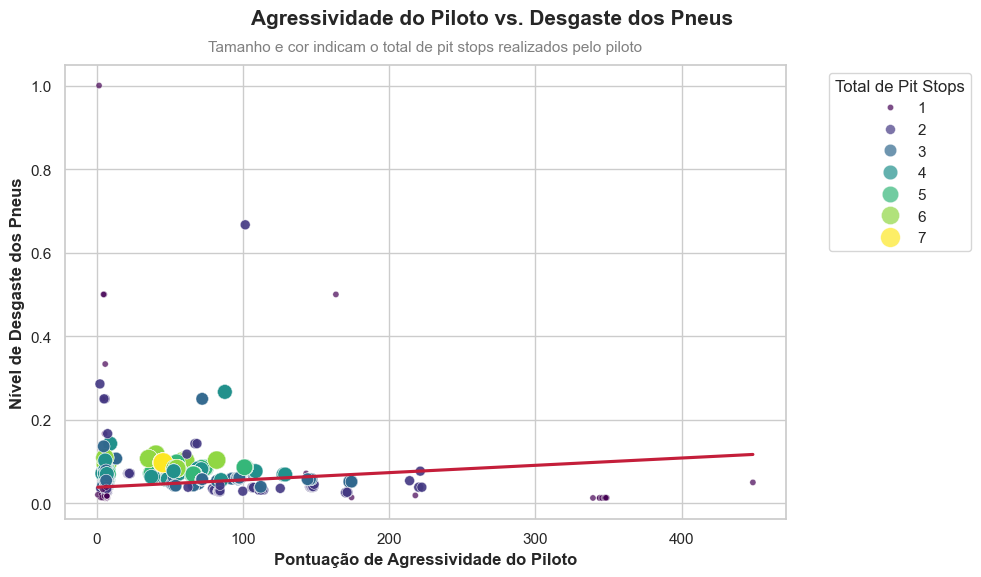

In [21]:
# Gráfico de Dispersão

print("Gráfico: Agressividade vs Desgaste com Cores...")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Gráfico de dispersão com TAMANHO e COR
sns.scatterplot(
    data=df_limpo,
    x='Driver Aggression Score',
    y='Tire Usage Aggression',
    size='TotalPitStops',
    hue='TotalPitStops',
    palette='viridis',
    sizes=(20, 200),
    alpha=0.7
)

# Linha de tendência
sns.regplot(
    data=df_limpo,
    x='Driver Aggression Score',
    y='Tire Usage Aggression',
    scatter=False,
    color="#c41e3a",
    ci=None
)


plt.suptitle("Agressividade do Piloto vs. Desgaste dos Pneus", fontsize=15, fontweight='bold', y=0.96)
plt.title("Tamanho e cor indicam o total de pit stops realizados pelo piloto", fontsize=11, color='gray', pad=10)
plt.xlabel("Pontuação de Agressividade do Piloto", fontweight='bold')
plt.ylabel("Nível de Desgaste dos Pneus", fontweight='bold')
plt.legend(title="Total de Pit Stops", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


─── Tempo Médio de Pit Stop por Temporada (2018–2024) ───


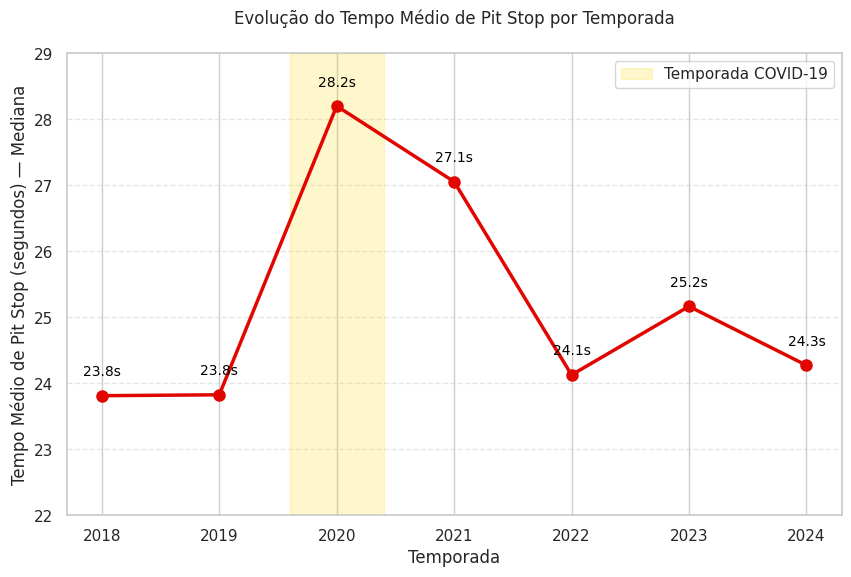

In [ ]:
# Grafico de Linha


print("\n─── Tempo Médio de Pit Stop por Temporada (2018–2024) ───")
#Formatação dos Dados
pit_por_temporada = (
    df_limpo.groupby('Season')['AvgPitStopTime']
    .median()
    .reset_index()
    .rename(columns={'AvgPitStopTime': 'Tempo Médio (s)'})
)

plt.figure(figsize=(10, 6))

plt.plot(
    pit_por_temporada['Season'],
    pit_por_temporada['Tempo Médio (s)'],
    marker='o', linewidth=2.5, color='#E10600', markersize=8
)

# Anotação do valor em cada ponto
for _, row in pit_por_temporada.iterrows():
    plt.text(row['Season'], row['Tempo Médio (s)'] + 0.3,
             f"{row['Tempo Médio (s)']:.1f}s",
             ha='center', fontsize=10, color='black')

# Destaque para 2020 (COVID-19)
plt.axvspan(2019.6, 2020.4, color='#FFD700', alpha=0.2, label='Temporada COVID-19')

plt.title('Evolução do Tempo Médio de Pit Stop por Temporada\n')
plt.xlabel('Temporada')
plt.ylabel('Tempo Médio de Pit Stop (segundos) — Mediana')
plt.ylim(22, 29)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Observa-se um aumento na mediana dos tempos de pit stop em torno da temporada de 2020, período marcado por mudanças operacionais relacionadas à pandemia.


─── Comprimento Médio dos Stints por Temporada e Composto ───


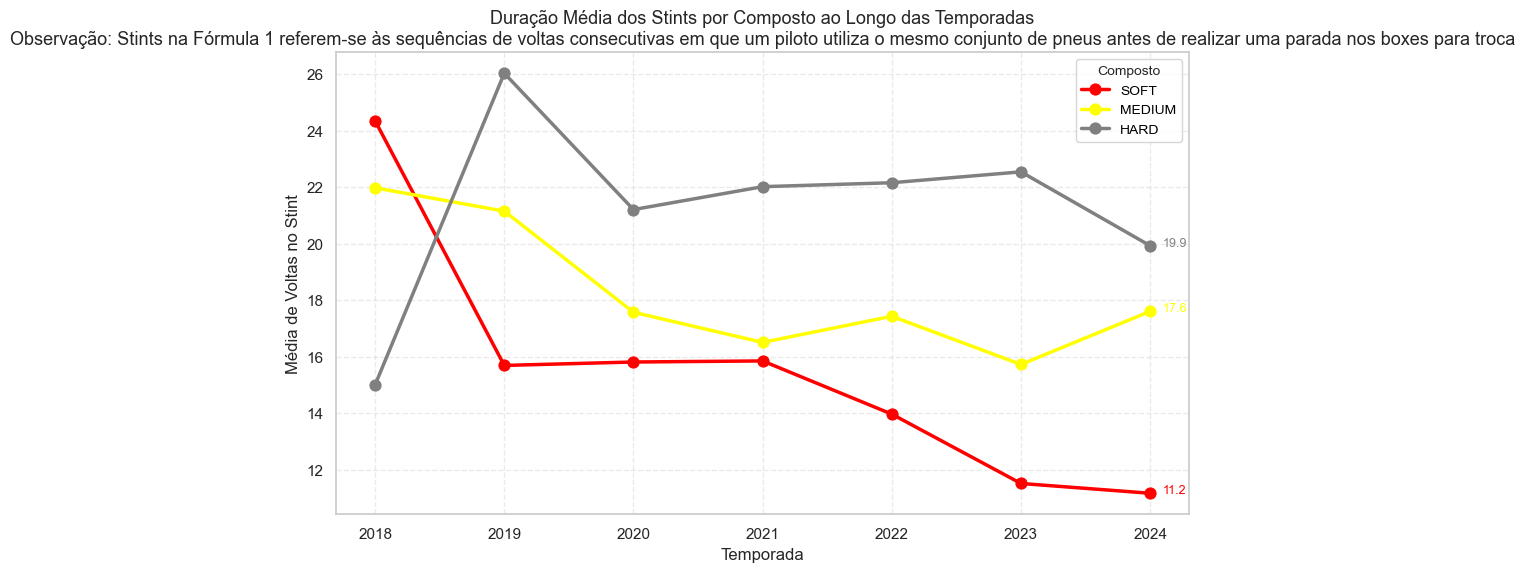

In [22]:
# Gráfico de Linha
# Comprimento Médio dos Stints por Temporada e Composto

print("\n─── Comprimento Médio dos Stints por Temporada e Composto ───")
#Formatação dos Dados
compostos_principais = ['SOFT', 'MEDIUM', 'HARD']
df_compostos = df_limpo[df_limpo['Tire Compound'].isin(compostos_principais)]

stint_compound = (
    df_compostos.groupby(['Season', 'Tire Compound'])['Stint Length']
    .mean()
    .reset_index()
    .rename(columns={'Stint Length': 'Stint Médio (voltas)'})
)


cores_compound = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'gray'}

plt.figure(figsize=(11, 6))

for composto in compostos_principais:
    sub = stint_compound[stint_compound['Tire Compound'] == composto]
    plt.plot(sub['Season'], sub['Stint Médio (voltas)'], marker='o', linewidth=2.5, label=composto, color=cores_compound[composto], markeredgecolor= cores_compound[composto], markeredgewidth=0.8, markersize=8)
    # Valor no último ponto de cada linha
    ultimo = sub.iloc[-1]
    plt.text(ultimo['Season'] + 0.1, ultimo['Stint Médio (voltas)'], f"{ultimo['Stint Médio (voltas)']:.1f}", fontsize=9, color=cores_compound[composto])

plt.title('Duração Média dos Stints por Composto ao Longo das Temporadas\n'
          'Observação: Stints na Fórmula 1 referem-se às sequências de voltas consecutivas em que um piloto utiliza o mesmo conjunto de pneus antes de realizar uma parada nos boxes para troca',
          fontsize=13)
plt.xlabel('Temporada')
plt.ylabel('Média de Voltas no Stint')
plt.legend(title='Composto', labelcolor='black', title_fontsize=10, fontsize=10)
plt.grid(linestyle='--', alpha=0.4)
plt.show()

Observasse que os Stints com pneus Soft encurtam cada vez mais, mostrando que as competidoras estão adotando a estratégia de pneu rápido e descartável.


─── Distribuição do Tempo Médio de Pit Stop por Piloto/Corrida ───
Média: 25.03s
Mediana: 23.76s


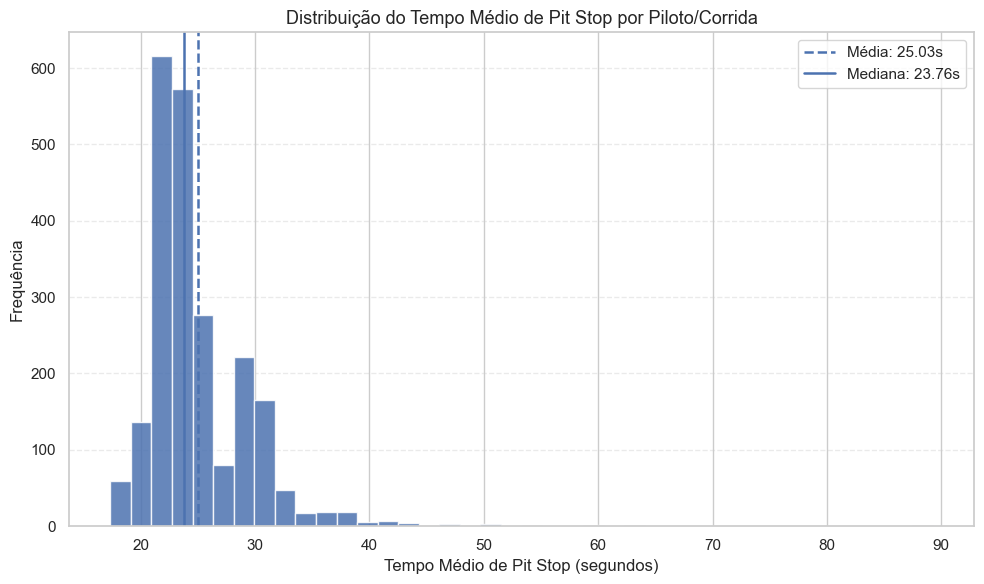

In [23]:
# Gráfico de Histograma

print("\n─── Distribuição do Tempo Médio de Pit Stop por Piloto/Corrida ───")

# Criar uma base com apenas um registro por piloto em cada corrida
df_pit_driver_race = (
    df_limpo
    .dropna(subset=['AvgPitStopTime'])
    .drop_duplicates(subset=['Season', 'Round', 'Driver'])
)

# Filtrar apenas tempos médios de pit stop até 120 segundos
df_pit = df_pit_driver_race[
    df_pit_driver_race['AvgPitStopTime'] <= 120
]

# Calcular média e mediana
media_pit = df_pit['AvgPitStopTime'].mean()
mediana_pit = df_pit['AvgPitStopTime'].median()

print(f"Média: {media_pit:.2f}s")
print(f"Mediana: {mediana_pit:.2f}s")

# Criar o histograma
plt.figure(figsize=(10, 6))

plt.hist(
    df_pit['AvgPitStopTime'],
    bins=40,
    edgecolor='white',
    alpha=0.85
)

# Linhas de média e mediana
plt.axvline(
    media_pit,
    linestyle='--',
    linewidth=1.8,
    label=f'Média: {media_pit:.2f}s'
)

plt.axvline(
    mediana_pit,
    linestyle='-',
    linewidth=1.8,
    label=f'Mediana: {mediana_pit:.2f}s'
)

plt.title(
    'Distribuição do Tempo Médio de Pit Stop por Piloto/Corrida',
    fontsize=13
)

plt.xlabel('Tempo Médio de Pit Stop (segundos)')
plt.ylabel('Frequência')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

A presença de paradas acima de 40 segundos revela que falhas operacionais e penalidades ainda ocorrem com frequência suficiente para impactar a média geral. Isso levanta uma hipótese importante: equipes com maior consistência nos tempos de pit stop tendem a ter melhor desempenho ao longo da temporada, já que uma parada lenta pode custar posições decisivas na corrida.

Boxplot — Driver Aggression Score por Piloto


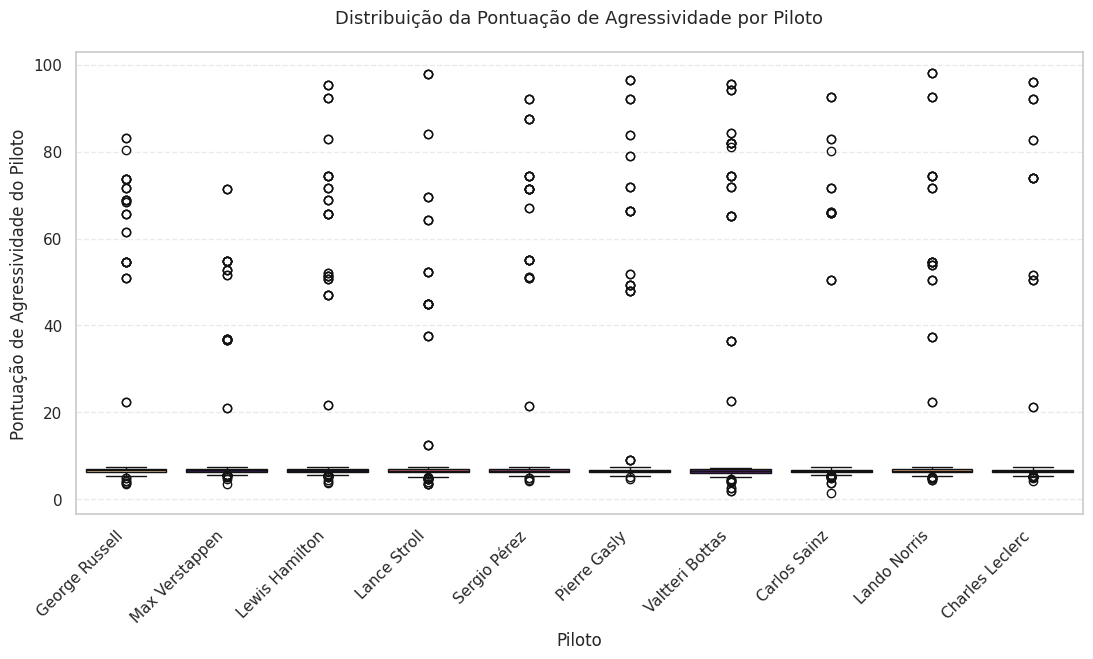

In [ ]:
#Grafico Boxplot

print("Boxplot — Driver Aggression Score por Piloto")

# Seleciona os 10 pilotos com mais dados para não poluir o gráfico
top10_pilotos = (
    df_limpo.groupby('Driver')['Driver Aggression Score']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Filtra outliers extremos de agressividade
df_box = df_limpo[
    (df_limpo['Driver'].isin(top10_pilotos)) &
    (df_limpo['Driver Aggression Score'] <= 100)
]

# Ordenar pelos pilotos com maior mediana
ordem = (
    df_box.groupby('Driver')['Driver Aggression Score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df_box,
    x='Driver', y='Driver Aggression Score',
    order=ordem,
    palette='magma',
    hue='Driver',
    legend=False
)

plt.title('Distribuição da Pontuação de Agressividade por Piloto\n', fontsize=13)
plt.xlabel('Piloto')
plt.ylabel('Pontuação de Agressividade do Piloto')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Todos os pilotos apresentam mediana muito próxima, entre 6 e 7 pontos, indicando que o comportamento de pilotagem é homogêneo no pelotão em condições normais de corrida. As diferenças reais entre pilotos não estão na tendência central, mas sim nos outliers, picos isolados de agressividade que chegam a 80-100 pontos e ocorrem em todos os pilotos sem exceção.